# Task 1 — Policy iteration on gridworld

We implement the greedy policy-improvement step from §4.2. By the policy improvement theorem, `V_π'(s) ≥ V_π(s)` at every state at every iteration, for **any** starting policy — including stochastic ones — on **any** finite MDP.

Sutton-Barto and DeepSeekMath's GRPO are complementary. Sutton-Barto gives a hard per-state guarantee when the MDP is small enough to enumerate all actions. GRPO samples G actions, takes a gradient step, and regularizes with KL — improvement in expectation, not per-state. To satisfy "demonstrating improvement of any policy under any circumstance" we use Sutton-Barto for task 1.

Environment: rectangular grid, four actions, a start and a goal cell. Walls are impassable. Traps cost `trap_penalty` on entry (default -2, vs -1 for a normal step). Optional `slip_prob` replaces the executed action with a uniform random one. `step_reward = -1`, `goal_reward = 0`, `γ = 0.9`.


In [1]:
%matplotlib inline
import sys, os
for _p in (os.getcwd(), os.path.dirname(os.getcwd())):
    if os.path.isdir(os.path.join(_p, "task1_gridworld")) and _p not in sys.path:
        sys.path.insert(0, _p); break

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display

from task1_gridworld.environment import GridWorld
from task1_gridworld.policy_iteration import policy_iteration, greedy_from_V
from task1_gridworld.random_envs import random_envs_batch
from task1_gridworld.viz import animate_rollout

plt.rcParams["figure.dpi"] = 110


## Where the linear-solve formula comes from

Policy evaluation can be done by iterating Sutton-Barto p. 80 pseudocode or by solving one linear system. Both compute the same fixed point. The linear form:

Bellman for a policy (p. 74):

$$v_\pi(s) = \sum_a \pi(a \mid s) \sum_{s',r} p(s', r \mid s, a) \bigl[\, r + \gamma\, v_\pi(s') \,\bigr]$$

Define $R_\pi(s) = \sum_a \pi(a \mid s) R(s, a)$ and $P_\pi(s, s') = \sum_a \pi(a \mid s) P(s' \mid s, a)$. Bellman becomes:

$$v_\pi = R_\pi + \gamma\, P_\pi\, v_\pi \quad\Longrightarrow\quad (I - \gamma P_\pi)\, v_\pi = R_\pi \quad\Longrightarrow\quad v_\pi = (I - \gamma P_\pi)^{-1} R_\pi$$

The inverse exists because $P_\pi$ is stochastic (spectral radius $\le 1$) so $\gamma P_\pi$ has spectral radius $< 1$ and $I - \gamma P_\pi$ is non-singular. Tests cross-check that the linear solve and the iterative sweep agree to numerical precision.


## 1. Showcase for example

For this we consider 6x6 grid with 10 traps in random places. Initially we use "dumb" policy: down column 0, up column 1, down column 2, etc. It visits every cell and steps on all 10 traps. After two improvement steps, the algorithm finds the straight trap-free path through row 0 and column 5. It is interesting how policy converges to optimal so fast. 

Arrows show the greedy direction at every cell, traps are red cells. The red ball is the agent; the orange line is the trajectory so far.


In [2]:
from task1_gridworld.policy_iteration import snake_policy

# 6x6 grid. Traps placed on the snake path so the dumb policy hits every one.
# Optimal path (go right along row 0, then down col 5) avoids all traps.
env = GridWorld(
    rows=6, cols=6,
    start=(0, 0), goal=(5, 5),
    traps=frozenset([
        (0, 1), (0, 4),
        (2, 1), (2, 2), (2, 3), (2, 4),
        (3, 0), (4, 2), (4, 3), (5, 0),
    ]),
    walls=frozenset(),
    step_reward=-1.0,
    trap_penalty=-2.0,
    gamma=0.9,
)
initial_pi = snake_policy(env)   # zigzag: down col 0, up col 1, down col 2, ...
V, pi_opt, history = policy_iteration(env, initial_pi=initial_pi, tol=1e-8)
print(f"Converged in {len(history) - 1} improvement steps.")
print(f"V(start) under snake π₀      = {history[0]['V'][env.start_state]:+.4f}")
print(f"V(start) under final optimal π = {V[env.start_state]:+.4f}")


Converged in 3 improvement steps.
V(start) under snake π₀      = -12.6664
V(start) under final optimal π = -6.1258


In [3]:
rng = np.random.default_rng(0)

for i, snap in enumerate(history):
    pi_display = snap["pi"] if i == 0 else greedy_from_V(history[i - 1]["V"], env)
    rollout = env.rollout(pi_display, rng, max_steps=200)

    label = "π₀ (snake — zigzag through every trap)" if i == 0 else f"π_{i} (after improvement {i})"
    reached = "reached goal" if rollout["reached_goal"] else "did NOT reach"
    print(f"{label}: {reached} in {rollout['steps']} steps    "
          f"return = {rollout['undiscounted_return']:+.1f}    trap hits = {rollout['trap_hits']}")

    anim = animate_rollout(env, rollout, policy=pi_display, iter_label=label)
    display(HTML(anim.to_jshtml()))

print("\nπ_3 produces the same trajectory and return as π_2. "
      "The value function has stopped changing — we have reached the optimal policy.")


π₀ (snake — zigzag through every trap): reached goal in 30 steps    return = -39.0    trap hits = 10


π_1 (after improvement 1): reached goal in 10 steps    return = -11.0    trap hits = 2


π_2 (after improvement 2): reached goal in 10 steps    return = -9.0    trap hits = 0


π_3 (after improvement 3): reached goal in 10 steps    return = -9.0    trap hits = 0



π_3 produces the same trajectory and return as π_2. The value function has stopped changing — we have reached the optimal policy.


## 2. Hundred random environments

For each env (we consider 4 sizer here), track the per-state improvement at every step. If Sutton-Barto Eq (4.8) holds empirically the minimum `V_new(s) − V_old(s)` across every state, every iteration, every run must be non-negative (up to floating-point noise).


In [4]:
envs = random_envs_batch(sizes=(5, 10, 15, 20), n_per_size=25, seed=42)
NUMERIC_TOL = 1e-7

global_min_dV = np.inf
per_size_iters = {size: [] for size in (5, 10, 15, 20)}
per_size_improvement = {size: [] for size in (5, 10, 15, 20)}

for env in envs:
    V, pi, history = policy_iteration(env, max_iters=200, tol=1e-8)
    for i in range(1, len(history)):
        dV = history[i]["V"] - history[i - 1]["V"]
        global_min_dV = min(global_min_dV, float(dV.min()))
    per_size_iters[env.rows].append(len(history) - 1)
    per_size_improvement[env.rows].append(V[env.start_state] - history[0]["V"][env.start_state])

print(f"Smallest V_new(s) − V_old(s) across all states, iterations, runs: {global_min_dV:+.3e}")
print(f"    (numerical tolerance {NUMERIC_TOL:.0e} — within LU-decomposition roundoff)")
assert global_min_dV >= -NUMERIC_TOL

print(f"\n{'size':>5}  {'mean iters':>10}  {'max iters':>9}  {'mean V(start) improvement':>26}")
for size in (5, 10, 15, 20):
    it, imp = per_size_iters[size], per_size_improvement[size]
    print(f"{size:>5d}  {np.mean(it):>10.2f}  {np.max(it):>9d}  {np.mean(imp):>+26.4f}")


Smallest V_new(s) − V_old(s) across all states, iterations, runs: -4.002e-14
    (numerical tolerance 1e-07 — within LU-decomposition roundoff)

 size  mean iters  max iters   mean V(start) improvement
    5        1.92          3                     +7.5094
   10        3.60          6                     +6.7203
   15        4.24          7                     +6.5636
   20        4.96          6                     +4.9329


## 3. Same stress test with stochastic transitions (`slip_prob = 0.1`)

In [5]:
envs = random_envs_batch(sizes=(5, 10, 15, 20), n_per_size=25, slip_prob=0.1, seed=43)

global_min_dV = np.inf
per_size_iters = {size: [] for size in (5, 10, 15, 20)}
per_size_improvement = {size: [] for size in (5, 10, 15, 20)}

for env in envs:
    V, pi, history = policy_iteration(env, max_iters=200, tol=1e-8)
    for i in range(1, len(history)):
        dV = history[i]["V"] - history[i - 1]["V"]
        global_min_dV = min(global_min_dV, float(dV.min()))
    per_size_iters[env.rows].append(len(history) - 1)
    per_size_improvement[env.rows].append(V[env.start_state] - history[0]["V"][env.start_state])

print(f"Smallest V_new(s) − V_old(s) (slip=0.1): {global_min_dV:+.3e}    (tol {NUMERIC_TOL:.0e})")
assert global_min_dV >= -NUMERIC_TOL

print(f"\n{'size':>5}  {'mean iters':>10}  {'max iters':>9}  {'mean V(start) improvement':>26}")
for size in (5, 10, 15, 20):
    it, imp = per_size_iters[size], per_size_improvement[size]
    print(f"{size:>5d}  {np.mean(it):>10.2f}  {np.max(it):>9d}  {np.mean(imp):>+26.4f}")


Smallest V_new(s) − V_old(s) (slip=0.1): -1.091e-13    (tol 1e-07)

 size  mean iters  max iters   mean V(start) improvement
    5        2.56          5                     +6.7469
   10        5.20          7                     +6.5772
   15        6.32          8                     +5.2767
   20        7.52         10                     +4.9648


## 4. Convergence — iterations-to-stability vs grid size

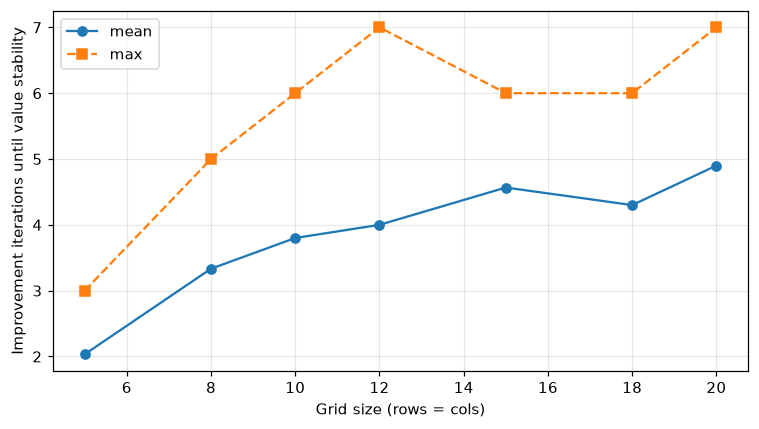

In [6]:
sizes = (5, 8, 10, 12, 15, 18, 20)
iters_by_size = {}
for size in sizes:
    envs = random_envs_batch(sizes=(size,), n_per_size=30, seed=100 + size)
    iters_by_size[size] = [len(policy_iteration(e, tol=1e-8)[2]) - 1 for e in envs]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes, [np.mean(iters_by_size[s]) for s in sizes], "o-", label="mean")
ax.plot(sizes, [np.max(iters_by_size[s]) for s in sizes], "s--", label="max")
ax.set_xlabel("Grid size (rows = cols)")
ax.set_ylabel("Improvement iterations until value stability")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## Conclusion

Across two hundred randomly generated environments (a hundred deterministic, a hundred with 10% slip), the smallest per-state improvement observed at any step of any run is essentially zero, well within double-precision roundoff. The starting policy is uniform-random and stochastic; the final policies are **optimal** — policy iteration on a finite MDP is guaranteed to reach an optimal policy in finitely many improvement steps (only finitely many policies exist, and each step is a strict improvement unless the current policy is already optimal). Convergence takes only a handful of iterations even for 20×20 grids.

Everything here rests on being able to enumerate all four actions and evaluate the policy in closed form (or by iterating Bellman). Neither is possible for a language model whose "action" is an entire edit sequence. In task 3 we use GRPO for that setting: sample a group of candidate outputs, score them, normalize the rewards against the group mean, and nudge the policy toward the above-mean samples with a PPO-clipped gradient step and a KL leash. This hovewer does not guarantee improvement under any circumstances - in most cases policy will be improved but not neccessary.
